In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import MultipleLocator

plt.rcParams.update({
   "font.family": "sans-serif",
   "font.sans-serif": ["Arial", "DejaVu Sans"],
   "font.size": 12,
   "axes.titlesize": 12,
   "axes.labelsize": 11,
   "xtick.labelsize": 11,
   "ytick.labelsize": 11,
   "legend.fontsize": 10,
   "axes.linewidth": 0.8,
   "xtick.major.size": 16,
   "xtick.major.width": 3,
   "ytick.major.size": 16,
   "ytick.major.width": 3,
   "xtick.minor.size": 10,
   "xtick.minor.width": 2.0,
   "ytick.minor.size": 10,
   "ytick.minor.width": 2.0,
   "xtick.minor.visible": True,
   "ytick.minor.visible": True,
   "xtick.direction": "out",
   "ytick.direction": "out",
   "xtick.major.pad": 15,
   "ytick.major.pad": 15,
   "xtick.minor.pad": 15,
   "ytick.minor.pad": 15,
   "axes.labelpad": 15,
   "axes.titlepad": 15,
})

In [2]:
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Arial"],
    "font.size":          12.0,   # global
    "axes.titlesize":     12.0,   # subplot title
    "axes.labelsize":     12.0,   # axis labels
    "xtick.labelsize":    11.0,   # tick labels slightly smaller
    "ytick.labelsize":    11.0,
    "legend.fontsize":    9.5,   # legend text

    # axes / ticks
    "axes.linewidth":     0.8,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "xtick.major.size":   3.5,
    "xtick.major.width":  0.8,
    "ytick.major.size":   3.5,
    "ytick.major.width":  0.8,
    "xtick.minor.size":   2.5,
    "xtick.minor.width":  0.5,
    "ytick.minor.size":   2.5,
    "ytick.minor.width":  0.5,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.pad":    4,
    "ytick.major.pad":    4,

    # spacing
    "axes.labelpad":      4,
    "axes.titlepad":      6,

    # default line width
    "lines.linewidth":    0.9,

    # no grid by default
    "axes.grid":          False,

    # savefig defaults
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

In [3]:
def calculate_metrics(simulated, observed):
    valid = ~(np.isnan(simulated) | np.isnan(observed))
    simulated_valid = simulated[valid]
    observed_valid = observed[valid]

    r_value = np.corrcoef(simulated_valid, observed_valid)[0, 1]
    rmse = np.sqrt(np.mean((simulated_valid - observed_valid) ** 2))
    mbe = np.mean(simulated_valid - observed_valid)
    return r_value, rmse, mbe

In [4]:
def setup_axis(axis, ylabel, title):
    axis.set_ylabel(ylabel)
    axis.set_xlabel("Site HL (-)")
    axis.set_title(title, loc="left", fontweight="bold")

    axis.set_xlim(0, 2.0)
    axis.set_ylim(0, 2.0)
    axis.plot((0, 2.0), (0, 2.0), ls="--", c="black")

    axis.tick_params(axis="x", which="major", top=False)
    axis.tick_params(axis="x", which="minor", top=False)
    axis.xaxis.set_minor_locator(MultipleLocator(0.1))
    axis.xaxis.set_major_locator(MultipleLocator(0.5))

    axis.tick_params(axis="y", which="major", right=False)
    axis.tick_params(axis="y", which="minor", right=False)
    axis.yaxis.set_minor_locator(MultipleLocator(0.1))
    axis.yaxis.set_major_locator(MultipleLocator(0.5))

    # for location in ["left", "right", "top", "bottom"]:
    #     axis.spines[location].set_linewidth(3.5)

In [7]:
def main():
    info = pd.read_csv("./data_for_HL_plot.csv")

    # fig = plt.figure(figsize=(35, 13), dpi=300)
    fig = plt.figure(figsize=(10, 4), dpi=300)
    colors = cm.tab20(np.linspace(0, 1, max(len(info), 20)))

    comparisons = [
        ("HL_GHSL", "GHSL_GBFP HL (-)", "(a) GHSL_GBFP HL vs Site HL"),
        ("HL_Li", "Li_GBFP HL (-)", "(b) Li_GBFP HL vs Site HL"),
    ]

    legend_handles = None
    legend_labels = None

    for idx, (column, ylabel, title) in enumerate(comparisons):
        axis = plt.subplot(1, 2, idx + 1)
        observed = info["HL_obs"].to_numpy(dtype=float)
        simulated = info[column].to_numpy(dtype=float)

        for site_idx, row in info.iterrows():
            axis.scatter(
                row["HL_obs"],
                row[column],
                s=40,
                c=[colors[site_idx]],
                # linewidths=0.5,
                edgecolor="black",
                lw=0.4,
                label=row["Site"],
                alpha=0.95,
            )

        r_value, rmse, mbe = calculate_metrics(simulated, observed)
        axis.text(
            0.04,
            0.97,
            f"R = {r_value:.2f}\nRMSE = {rmse:.2f}\nMBE = {mbe:.2f}",
            ha="left",
            va="top",
            transform=axis.transAxes,
        )

        setup_axis(axis, ylabel, title)
        legend_handles, legend_labels = axis.get_legend_handles_labels()

    unique_labels = dict(zip(legend_labels, legend_handles))
    fig.legend(
        unique_labels.values(),
        unique_labels.keys(),
        loc="lower center",
        ncol=5,
        frameon=False,
        bbox_to_anchor=(0.5, -0.25),
    )

    fig.subplots_adjust(wspace=0.35)
    plt.savefig("./Fig4.pdf", format="pdf", bbox_inches="tight", dpi=300)

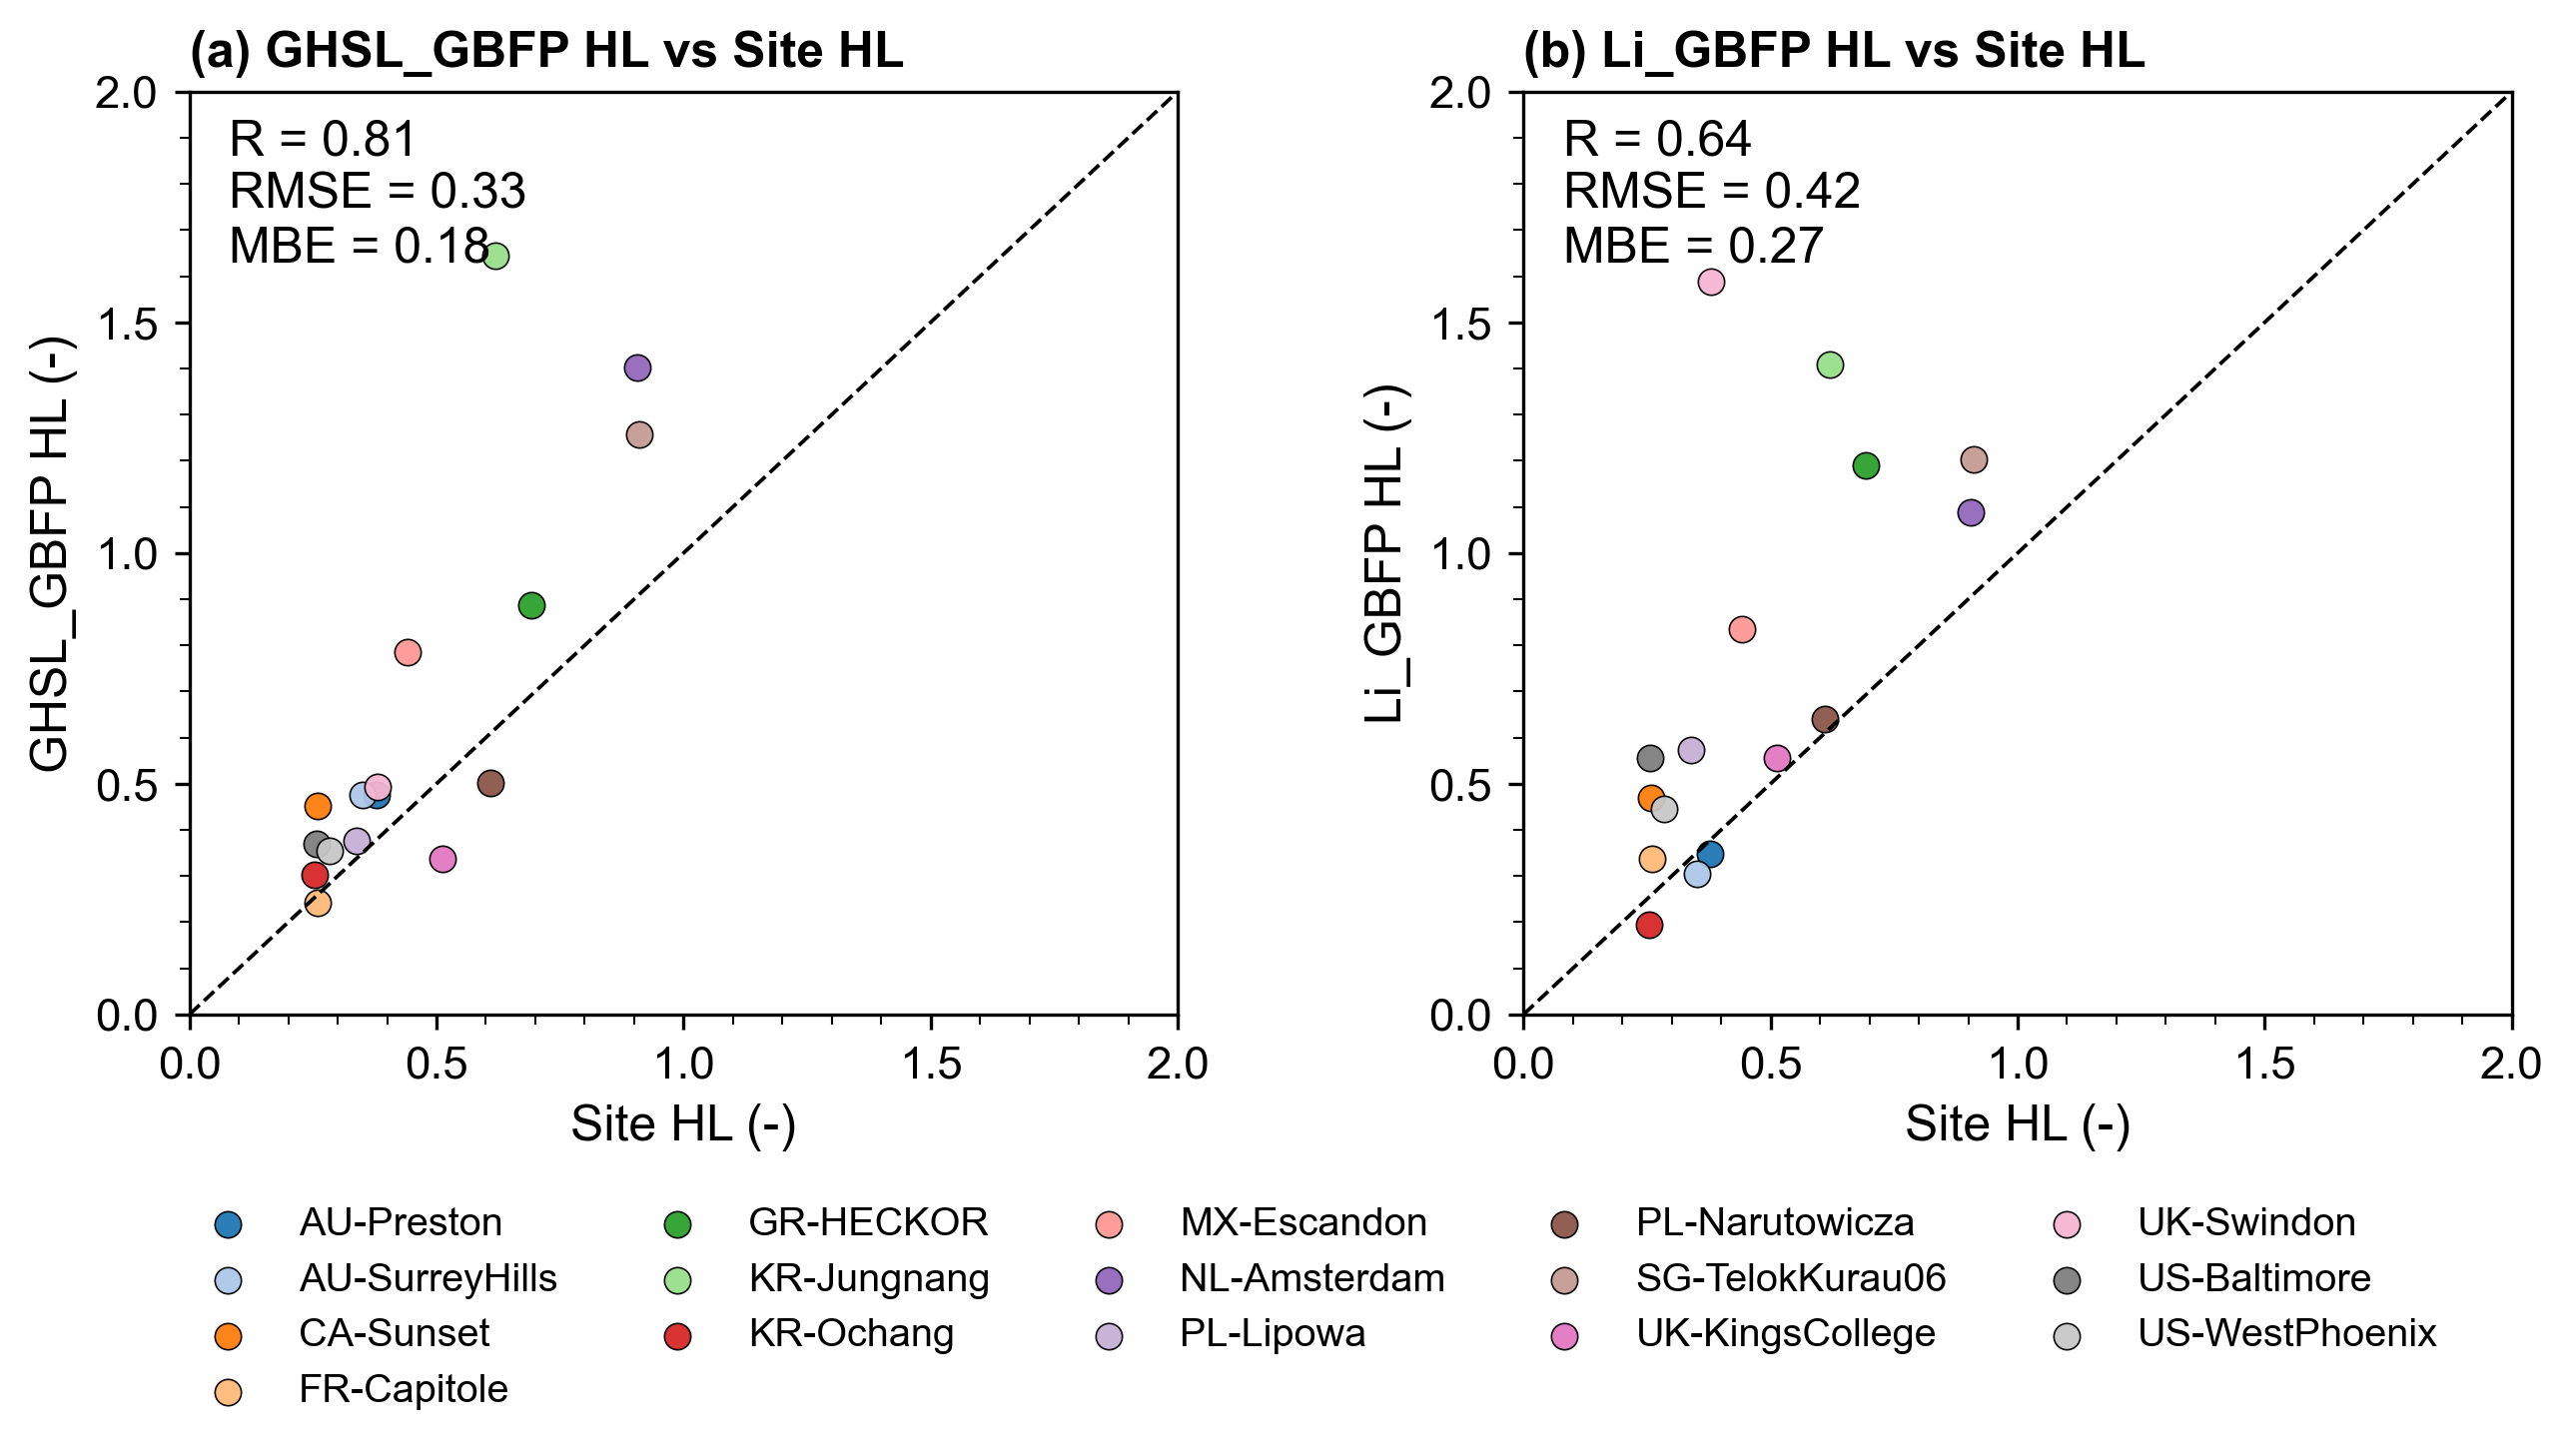

In [8]:
if __name__ == "__main__":
    main()